In [1]:
# Hallucination metrics: compute CHAIR_i/CHAIR_s and ALOHa per image,
# then correlate them with GSCS. Loads the three captioning CSVs
# from outputs/project_*/results/. Optional install of
# sentence-transformers enables the ALOHa SBERT embedding; otherwise
# the notebook falls back to
# WordNet Wu-Palmer similarity (coarser, no torch / no model download).

# Uncomment to install in a fresh environment.
# %pip install -q sentence-transformers
import importlib
HAS_SBERT = importlib.util.find_spec("sentence_transformers") is not None
print("sentence-transformers available:", HAS_SBERT)


sentence-transformers available: False


In [2]:
import os, ast, json, zipfile, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk import word_tokenize, pos_tag
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet as wn

from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings("ignore", category=UserWarning)

for pkg in ("punkt", "punkt_tab", "averaged_perceptron_tagger_eng",
            "averaged_perceptron_tagger", "wordnet", "omw-1.4"):
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

SEED = 42
np.random.seed(SEED)

OUTPUTS_DIR = os.path.abspath("outputs")
BASE_DIR    = os.path.join(OUTPUTS_DIR, "project_hallucination")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
FIGURES_DIR = os.path.join(BASE_DIR, "figures")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

MODEL_CSV_PATHS = {
    "BLIP":     (os.path.join(OUTPUTS_DIR, "project_blip",         "results", "blip_full_results.csv"),    "blip"),
    "ViT-GPT2": (os.path.join(OUTPUTS_DIR, "project_vitgpt2",      "results", "vitgpt2_full_results.csv"), "vitgpt2"),
    "ClipCap":  (os.path.join(OUTPUTS_DIR, "project_clipcap_full", "results", "clipcap_full_results.csv"), "clipcap"),
}

IGNORE_WORDS = {
    "image", "photo", "picture", "scene", "background", "front", "top", "side",
}

ALOHA_TAU = 0.5

print("Output dir:", BASE_DIR)
print("Models    :", list(MODEL_CSV_PATHS))


Output dir: c:\Users\William\Desktop\Vision2Text\Vision2Text\outputs\project_hallucination
Models    : ['BLIP', 'ViT-GPT2', 'ClipCap']


In [3]:
# Load per-image outputs of the three captioning notebooks.

def _safe_parse_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str) and x.strip().startswith("["):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []

frames = []
for model_name, (csv_path, prefix) in MODEL_CSV_PATHS.items():
    if not os.path.isfile(csv_path):
        raise FileNotFoundError(
            f"Missing {csv_path}. Run the {model_name} notebook first."
        )
    df = pd.read_csv(csv_path)

    keep_cols = {
        "image":              "image",
        "image_path":         "image_path",
        "caption":            "ref_captions",          # list of 5 reference captions
        f"{prefix}_caption":  "gen_caption",
        f"{prefix}_objects":  "cap_objects",           # NLTK + IGNORE_WORDS
        f"{prefix}_grounded_objects": "det_objects",   # Grounding DINO
        f"{prefix}_object_count":     "n_cap_objects",
        f"{prefix}_grounded_count":   "n_grounded",
        f"{prefix}_gscs":             "gscs",
        f"{prefix}_hallucination_rate": "gscs_halluc_rate",
        f"{prefix}_clipscore":        "clipscore",
        f"{prefix}_gscs_status":      "gscs_status",
    }
    df = df[list(keep_cols)].rename(columns=keep_cols)
    df["model"] = model_name
    df["ref_captions"] = df["ref_captions"].apply(_safe_parse_list)
    df["cap_objects"]  = df["cap_objects"].apply(_safe_parse_list)
    df["det_objects"]  = df["det_objects"].apply(_safe_parse_list)
    frames.append(df)

per_image = pd.concat(frames, ignore_index=True)

# Restrict to images all 3 models share.
shared_images = set.intersection(*[
    set(per_image.loc[per_image["model"] == m, "image"]) for m in MODEL_CSV_PATHS
])
per_image = per_image[per_image["image"].isin(shared_images)].reset_index(drop=True)

print("Per-model image counts:",
      per_image.groupby("model")["image"].nunique().to_dict())
print("Shared images:", len(shared_images))
print("Total (model x image) rows:", len(per_image))
per_image.head(3)


Per-model image counts: {'BLIP': 50, 'ClipCap': 50, 'ViT-GPT2': 50}
Shared images: 50
Total (model x image) rows: 150


,image,image_path,ref_captions,gen_caption,cap_objects,det_objects,n_cap_objects,n_grounded,gscs,gscs_halluc_rate,clipscore,gscs_status,model
0,1000092795.jpg,c:\Users\William\Desktop\Vision2Text\Vision2Te...,[Two young guys with shaggy hair look at their...,a man standing in the grass,"[man, grass]",[man],2,1,0.500000,0.500000,26.660156,ok,BLIP
1,10002456.jpg,c:\Users\William\Desktop\Vision2Text\Vision2Te...,[Several men in hard hats are operating a gian...,the sky is white,[sky],[sky],1,1,1.000000,0.000000,19.702148,ok,BLIP
2,1000268201.jpg,c:\Users\William\Desktop\Vision2Text\Vision2Te...,[A child in a pink dress is climbing up a set ...,a little girl in a pink dress,"[girl, pink, dress]","[pink a dress, girl]",3,1,0.333333,0.666667,24.572754,ok,BLIP


In [4]:
# Build the per-image reference object set O_ref.

_lemmatizer = WordNetLemmatizer()

def extract_objects(text, ignore=IGNORE_WORDS):
    """Extract nouns with NLTK POS tagging and WordNet lemmatisation."""
    tokens = word_tokenize(str(text).lower())
    tags = pos_tag(tokens)
    out = []
    seen = set()
    for w, t in tags:
        if t in {"NN", "NNS", "NNP", "NNPS"}:
            lemma = _lemmatizer.lemmatize(w, pos="n").strip().lower()
            if lemma.isalpha() and lemma not in ignore and lemma not in seen:
                seen.add(lemma)
                out.append(lemma)
    return out

def ref_objects(ref_captions, ignore=IGNORE_WORDS):
    """Return union of extracted nouns across reference captions."""
    out, seen = [], set()
    for r in ref_captions:
        for o in extract_objects(r, ignore=ignore):
            if o not in seen:
                seen.add(o)
                out.append(o)
    return out

# Reference set is per *image* (not per model). Compute once on BLIP rows
# and broadcast back.
ref_per_image = (
    per_image.drop_duplicates("image")
             .assign(ref_objects=lambda d: d["ref_captions"].apply(ref_objects))
             [["image", "ref_objects"]]
)
per_image = per_image.merge(ref_per_image, on="image", how="left")

print("Mean |O_ref| per image:", per_image.drop_duplicates("image")["ref_objects"].apply(len).mean().round(2))
print("Sample O_ref:", per_image.drop_duplicates("image").iloc[0]["ref_objects"])


Mean |O_ref| per image: 11.8
Sample O_ref: ['guy', 'hair', 'look', 'hand', 'yard', 'male', 'bush', 'men', 'shirt', 'man', 'garden', 'friend', 'time']


In [5]:
# Compute CHAIR_i and CHAIR_s per image.

rows_chair = []
for _, r in per_image.iterrows():
    O_cap = list(r["cap_objects"])
    O_ref = set(r["ref_objects"])
    n_cap = len(O_cap)
    halluc = [o for o in O_cap if o not in O_ref]
    n_h    = len(halluc)

    if n_cap == 0:
        chair_i = 0.0       # nothing said -> nothing to hallucinate
        chair_s = 0
        n_cap_eff = 0
    else:
        chair_i = n_h / n_cap
        chair_s = int(n_h >= 1)
        n_cap_eff = n_cap

    rows_chair.append({
        "model": r["model"], "image": r["image"],
        "n_cap_objects": n_cap_eff,
        "n_hallucinated": n_h,
        "hallucinated_objects": halluc,
        "chair_i": chair_i,
        "chair_s": chair_s,
    })
chair_df = pd.DataFrame(rows_chair)
chair_df.to_csv(os.path.join(RESULTS_DIR, "chair_per_image.csv"), index=False)

chair_summary = (chair_df.groupby("model")
    .agg(n_images=("image", "nunique"),
         mean_chair_i=("chair_i", "mean"),
         corpus_chair_i=("n_hallucinated", lambda s:
             s.sum() / max(chair_df.loc[s.index, "n_cap_objects"].sum(), 1)),
         chair_s=("chair_s", "mean"))
    .reset_index())

# Re-express as percentages so they line up with the Rohrbach et al. paper.
chair_summary["mean_chair_i_%"]   = (chair_summary["mean_chair_i"]   * 100).round(2)
chair_summary["corpus_chair_i_%"] = (chair_summary["corpus_chair_i"] * 100).round(2)
chair_summary["chair_s_%"]        = (chair_summary["chair_s"]        * 100).round(2)
chair_summary


,model,n_images,mean_chair_i,corpus_chair_i,chair_s,mean_chair_i_%,corpus_chair_i_%,chair_s_%
0,BLIP,50,0.355000,0.314050,0.60,35.50,31.40,60.0
1,ClipCap,50,0.850000,0.902439,0.86,85.00,90.24,86.0
2,ViT-GPT2,50,0.444333,0.467105,0.74,44.43,46.71,74.0


In [6]:
# Build the ALOHa similarity backbone (SBERT preferred,
# WordNet Wu-Palmer fallback).
ENCODE_MODEL_NAME = None
_encode_cache = {}

if HAS_SBERT:
    from sentence_transformers import SentenceTransformer
    _sbert = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    ENCODE_MODEL_NAME = "sbert/all-MiniLM-L6-v2"

    def _encode(words):
        words = list(words)
        missing = [w for w in words if w not in _encode_cache]
        if missing:
            embs = _sbert.encode(missing, normalize_embeddings=True,
                                 show_progress_bar=False)
            for w, e in zip(missing, embs):
                _encode_cache[w] = e
        return np.stack([_encode_cache[w] for w in words])

    def max_sim(o, pool):
        if not pool:
            return 0.0
        E = _encode([o] + list(pool))                # (1+P, d), normalized
        sims = E[0] @ E[1:].T                        # cosine similarities
        return float(sims.max())

else:
    ENCODE_MODEL_NAME = "wordnet/wup"
    def _wn_sim(a, b):
        sa = wn.synsets(a, pos="n")
        sb = wn.synsets(b, pos="n")
        if not sa or not sb:
            return 0.0
        best = 0.0
        for x in sa[:3]:                             # cap synset count
            for y in sb[:3]:
                v = x.wup_similarity(y)
                if v is not None and v > best:
                    best = v
        return float(best)

    def max_sim(o, pool):
        if not pool:
            return 0.0
        if o in pool:
            return 1.0
        return max(_wn_sim(o, p) for p in pool)

print("ALOHa similarity backbone:", ENCODE_MODEL_NAME)


ALOHa similarity backbone: wordnet/wup


In [7]:
def _aloha_for_pool(O_cap, pool):
    if not O_cap:
        return {"aloha_score": 1.0, "halluc_frac": 0.0,
                "aloha_s": 0, "n_halluc": 0, "sims": []}
    sims = [max_sim(o, pool) for o in O_cap]
    n_h  = sum(1 for s in sims if s < ALOHA_TAU)
    return {
        "aloha_score": float(np.mean(sims)),
        "halluc_frac": n_h / len(O_cap),
        "aloha_s":     int(n_h >= 1),
        "n_halluc":    n_h,
        "sims":        sims,
    }

rows_aloha = []
for _, r in per_image.iterrows():
    O_cap = list(r["cap_objects"])
    O_ref = list(r["ref_objects"])
    O_det = list(r["det_objects"])

    canonical = _aloha_for_pool(O_cap, sorted(set(O_ref)))
    open_set  = _aloha_for_pool(O_cap, sorted(set(O_ref) | set(O_det)))

    rows_aloha.append({
        "model": r["model"], "image": r["image"],
        "n_cap_objects": len(O_cap),
        "aloha_i_score":         canonical["aloha_score"],
        "aloha_i_halluc_frac":   canonical["halluc_frac"],
        "aloha_s":               canonical["aloha_s"],
        "n_aloha_halluc":        canonical["n_halluc"],
        "aloha_max_sims_per_obj":canonical["sims"],
        "alohaOD_i_score":       open_set["aloha_score"],
        "alohaOD_i_halluc_frac": open_set["halluc_frac"],
        "alohaOD_s":             open_set["aloha_s"],
        "n_alohaOD_halluc":      open_set["n_halluc"],
    })
aloha_df = pd.DataFrame(rows_aloha)
aloha_df.to_csv(os.path.join(RESULTS_DIR, "aloha_per_image.csv"), index=False)

def _agg(name_score, name_n_halluc, name_s):
    return (aloha_df.groupby("model")
        .agg(n_images=("image", "nunique"),
             score=(name_score, "mean"),
             corpus_halluc=(name_n_halluc, lambda s:
                 s.sum() / max(aloha_df.loc[s.index, "n_cap_objects"].sum(), 1)),
             halluc_s=(name_s, "mean"))
        .reset_index())

aloha_summary    = _agg("aloha_i_score",    "n_aloha_halluc",   "aloha_s")
alohaOD_summary  = _agg("alohaOD_i_score",  "n_alohaOD_halluc", "alohaOD_s")
aloha_summary["variant"]   = "ALOHa (O_ref only)"
alohaOD_summary["variant"] = "ALOHa-OD (O_ref + O_det)"

aloha_combined = pd.concat([aloha_summary, alohaOD_summary], ignore_index=True)
aloha_combined["score"]               = aloha_combined["score"].round(4)
aloha_combined["corpus_halluc_%"]     = (aloha_combined["corpus_halluc"] * 100).round(2)
aloha_combined["halluc_s_%"]          = (aloha_combined["halluc_s"]      * 100).round(2)
aloha_combined.to_csv(os.path.join(RESULTS_DIR, "aloha_summary.csv"), index=False)
aloha_combined[["variant", "model", "n_images", "score",
                "corpus_halluc_%", "halluc_s_%"]]


,variant,model,n_images,score,corpus_halluc_%,halluc_s_%
0,ALOHa (O_ref only),BLIP,50,0.9114,0.00,0.0
1,ALOHa (O_ref only),ClipCap,50,0.7468,4.88,8.0
2,ALOHa (O_ref only),ViT-GPT2,50,0.8819,1.97,6.0
3,ALOHa-OD (O_ref + O_det),BLIP,50,0.9812,0.00,0.0
4,ALOHa-OD (O_ref + O_det),ClipCap,50,0.9154,3.66,6.0
5,ALOHa-OD (O_ref + O_det),ViT-GPT2,50,0.9448,1.32,4.0


In [8]:
# Build combined per-image metrics table and headline summary.

metrics_per_image = (per_image[[
        "model", "image", "gen_caption",
        "n_cap_objects", "n_grounded",
        "gscs", "gscs_halluc_rate", "clipscore",
    ]]
    .merge(chair_df[["model", "image", "chair_i", "chair_s",
                     "n_hallucinated"]],
           on=["model", "image"])
    .merge(aloha_df[["model", "image",
                     "aloha_i_score", "aloha_i_halluc_frac", "aloha_s",
                     "n_aloha_halluc",
                     "alohaOD_i_score", "alohaOD_i_halluc_frac", "alohaOD_s",
                     "n_alohaOD_halluc"]],
           on=["model", "image"]))

metrics_per_image.to_csv(
    os.path.join(RESULTS_DIR, "metrics_per_image.csv"), index=False
)

summary = (metrics_per_image.groupby("model")
    .agg(n_images=("image", "nunique"),
         GSCS=("gscs", "mean"),
         GSCS_halluc_rate=("gscs_halluc_rate", "mean"),
         CHAIR_i=("chair_i", "mean"),
         CHAIR_s=("chair_s", "mean"),
         ALOHa=("aloha_i_score", "mean"),
         ALOHa_halluc_frac=("aloha_i_halluc_frac", "mean"),
         ALOHa_s=("aloha_s", "mean"),
         ALOHa_OD=("alohaOD_i_score", "mean"),
         ALOHa_OD_s=("alohaOD_s", "mean"),
         CLIPScore=("clipscore", "mean"))
    .reset_index())

disp = summary.copy()
for c in ["GSCS", "GSCS_halluc_rate", "CHAIR_i", "CHAIR_s",
          "ALOHa", "ALOHa_halluc_frac", "ALOHa_s",
          "ALOHa_OD", "ALOHa_OD_s"]:
    disp[c] = disp[c].round(4)
disp["CLIPScore"] = disp["CLIPScore"].round(2)
disp.to_csv(os.path.join(RESULTS_DIR, "hallucination_summary.csv"), index=False)
disp


,model,n_images,GSCS,GSCS_halluc_rate,CHAIR_i,CHAIR_s,ALOHa,ALOHa_halluc_frac,ALOHa_s,ALOHa_OD,ALOHa_OD_s,CLIPScore
0,BLIP,50,0.8433,0.1567,0.3550,0.60,0.9114,0.0000,0.00,0.9812,0.00,27.70
1,ClipCap,50,0.7417,0.2583,0.8500,0.86,0.7468,0.0240,0.08,0.9154,0.06,20.39
2,ViT-GPT2,50,0.7057,0.2943,0.4443,0.74,0.8819,0.0157,0.06,0.9448,0.04,27.56


In [9]:
# Per-image Pearson and Spearman: GSCS vs CHAIR / ALOHa per model.

def corr_block(sub):
    """Compute Pearson and Spearman of (GSCS, 1-CHAIR_i, ALOHa, ALOHa-OD)."""
    g   = sub["gscs"].to_numpy()
    c   = 1.0 - sub["chair_i"].to_numpy()
    a   = sub["aloha_i_score"].to_numpy()
    aod = sub["alohaOD_i_score"].to_numpy()

    out = {}
    for name, x, y in [
        ("gscs_vs_invchair", g,   c),
        ("gscs_vs_aloha",    g,   a),
        ("gscs_vs_alohaOD",  g,   aod),
        ("invchair_vs_aloha",c,   a),
        ("aloha_vs_alohaOD", a,   aod),
    ]:
        if np.std(x) == 0 or np.std(y) == 0:
            out[f"{name}_pearson"]  = np.nan
            out[f"{name}_spearman"] = np.nan
        else:
            out[f"{name}_pearson"]  = float(pearsonr(x, y)[0])
            out[f"{name}_spearman"] = float(spearmanr(x, y)[0])
    return pd.Series(out)

corr_per_model = (metrics_per_image
    .groupby("model")
    .apply(corr_block)
    .reset_index())

for c in corr_per_model.columns:
    if c != "model":
        corr_per_model[c] = corr_per_model[c].round(3)

corr_per_model.to_csv(os.path.join(RESULTS_DIR, "correlation_matrix.csv"),
                      index=False)
corr_per_model


C:\Users\William\AppData\Local\Temp\ipykernel_15464\2403716568.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(corr_block)


,model,gscs_vs_invchair_pearson,gscs_vs_invchair_spearman,gscs_vs_aloha_pearson,gscs_vs_aloha_spearman,gscs_vs_alohaOD_pearson,gscs_vs_alohaOD_spearman,invchair_vs_aloha_pearson,invchair_vs_aloha_spearman,aloha_vs_alohaOD_pearson,aloha_vs_alohaOD_spearman
0,BLIP,-0.040,-0.100,-0.103,-0.098,0.607,0.615,0.884,0.918,0.245,0.309
1,ClipCap,0.150,0.191,0.314,0.337,0.882,0.922,0.752,0.615,0.498,0.465
2,ViT-GPT2,0.326,0.343,0.434,0.408,0.707,0.736,0.853,0.856,0.754,0.762


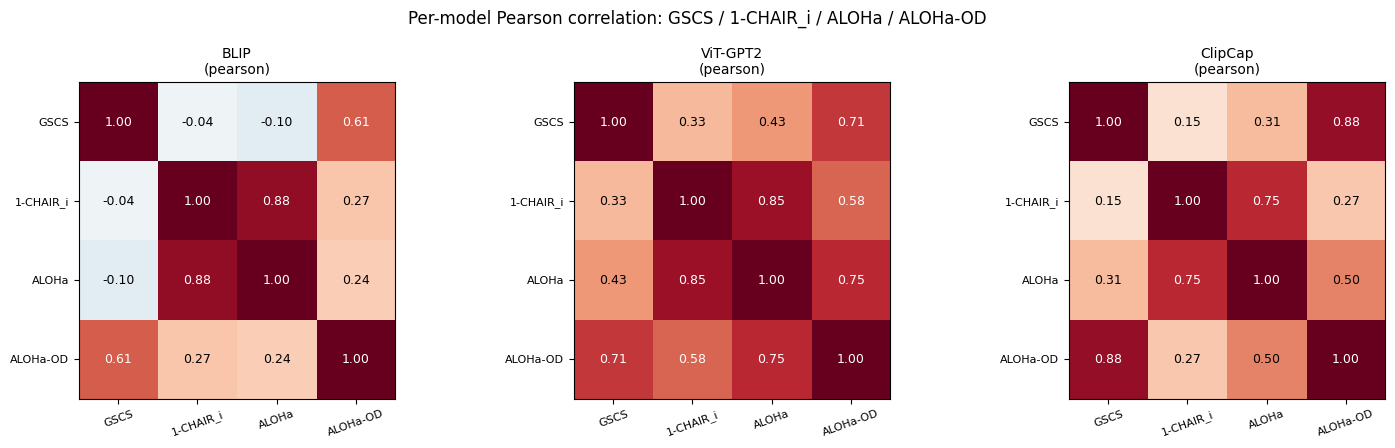

In [10]:
# Plot per-model correlation heatmap (Pearson and Spearman).

def make_heatmap(metrics_per_image, ax, model_name, kind="pearson"):
    sub = metrics_per_image[metrics_per_image["model"] == model_name]
    arr = np.stack([
        sub["gscs"].to_numpy(),
        1.0 - sub["chair_i"].to_numpy(),
        sub["aloha_i_score"].to_numpy(),
        sub["alohaOD_i_score"].to_numpy(),
    ])
    n = arr.shape[0]
    if kind == "spearman":
        rho = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                if np.std(arr[i]) == 0 or np.std(arr[j]) == 0:
                    rho[i, j] = np.nan
                else:
                    rho[i, j] = spearmanr(arr[i], arr[j])[0]
    else:
        if any(np.std(arr[i]) == 0 for i in range(n)):
            rho = np.full((n, n), np.nan)
            for i in range(n):
                rho[i, i] = 1.0
        else:
            rho = np.corrcoef(arr)

    im = ax.imshow(rho, cmap="RdBu_r", vmin=-1, vmax=1)
    labels = ["GSCS", "1-CHAIR_i", "ALOHa", "ALOHa-OD"]
    ax.set_xticks(range(n)); ax.set_xticklabels(labels, fontsize=8, rotation=20)
    ax.set_yticks(range(n)); ax.set_yticklabels(labels, fontsize=8)
    for i in range(n):
        for j in range(n):
            v = rho[i, j]
            txt = "n/a" if np.isnan(v) else f"{v:.2f}"
            ax.text(j, i, txt, ha="center", va="center",
                    color="white" if abs(v if not np.isnan(v) else 0) > 0.5 else "black",
                    fontsize=9)
    ax.set_title(f"{model_name}\n({kind})", fontsize=10)
    return im

models = sorted(metrics_per_image["model"].unique(),
                key=lambda m: ["BLIP", "ViT-GPT2", "ClipCap"].index(m))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, m in zip(axes, models):
    im = make_heatmap(metrics_per_image, ax, m, kind="pearson")
fig.suptitle("Per-model Pearson correlation: GSCS / 1-CHAIR_i / ALOHa / ALOHa-OD",
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "per_model_correlation_heatmap.png"),
            dpi=200, bbox_inches="tight")
plt.show()


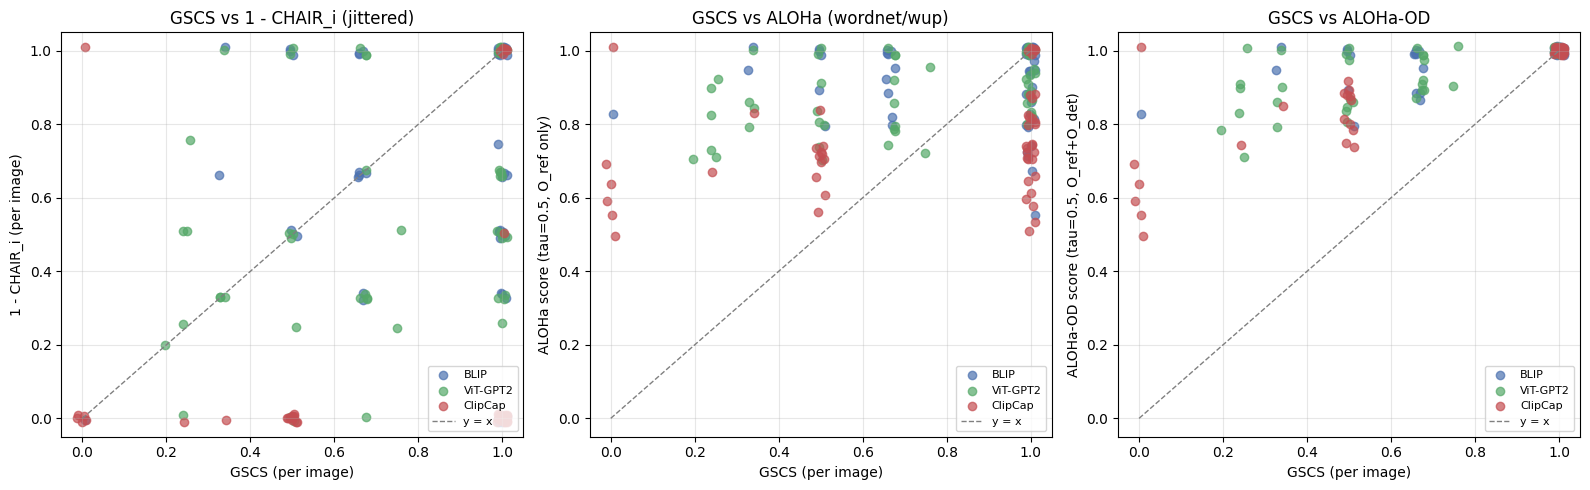

In [11]:
# Per-image scatter: GSCS vs (1 - CHAIR_i) and GSCS vs ALOHa.

COLOR = {"BLIP": "#4C72B0", "ViT-GPT2": "#55A868", "ClipCap": "#C44E52"}

def _scatter(ax, ycol_or_fn, ylabel, title):
    np.random.seed(SEED)
    for m in models:
        sub = metrics_per_image[metrics_per_image["model"] == m]
        jitter = 0.012
        xv = sub["gscs"].to_numpy() + np.random.uniform(-jitter, jitter, len(sub))
        if callable(ycol_or_fn):
            yv = ycol_or_fn(sub)
        else:
            yv = sub[ycol_or_fn].to_numpy()
        yv = yv + np.random.uniform(-jitter, jitter, len(sub))
        ax.scatter(xv, yv, s=36, alpha=0.7, color=COLOR[m], label=m)
    ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="y = x")
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("GSCS (per image)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=8); ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
_scatter(axes[0], lambda s: 1.0 - s["chair_i"].to_numpy(),
         "1 - CHAIR_i (per image)",
         "GSCS vs 1 - CHAIR_i (jittered)")
_scatter(axes[1], "aloha_i_score",
         f"ALOHa score (tau={ALOHA_TAU}, O_ref only)",
         f"GSCS vs ALOHa ({ENCODE_MODEL_NAME})")
_scatter(axes[2], "alohaOD_i_score",
         f"ALOHa-OD score (tau={ALOHA_TAU}, O_ref+O_det)",
         "GSCS vs ALOHa-OD")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "gscs_vs_chair_aloha_scatter.png"),
            dpi=200, bbox_inches="tight")
plt.show()


In [12]:
# Corpus-level ranking under each metric.

metric_cols = ["GSCS", "ALOHa", "ALOHa_OD", "CLIPScore"]
inv_cols    = ["GSCS_halluc_rate", "CHAIR_i", "CHAIR_s",
               "ALOHa_halluc_frac", "ALOHa_s", "ALOHa_OD_s"]

corpus = summary.set_index("model")[metric_cols + inv_cols].copy()

ranks_higher_better = corpus[metric_cols].rank(ascending=False, method="min")
ranks_lower_better  = corpus[inv_cols].rank(ascending=True,  method="min")
ranks = pd.concat([ranks_higher_better, ranks_lower_better], axis=1)

def ordering(series, ascending):
    return " > ".join(series.sort_values(ascending=ascending).index)

ordering_rows = []
for c in metric_cols:
    ordering_rows.append({"metric": c, "direction": "higher better",
                          "ranking": ordering(corpus[c], ascending=False)})
for c in inv_cols:
    ordering_rows.append({"metric": c, "direction": "lower better",
                          "ranking": ordering(corpus[c], ascending=True)})
ranking_df = pd.DataFrame(ordering_rows)
ranking_df.to_csv(os.path.join(RESULTS_DIR, "ranking_agreement.csv"),
                  index=False)
ranking_df


,metric,direction,ranking
0,GSCS,higher better,BLIP > ClipCap > ViT-GPT2
1,ALOHa,higher better,BLIP > ViT-GPT2 > ClipCap
2,ALOHa_OD,higher better,BLIP > ViT-GPT2 > ClipCap
3,CLIPScore,higher better,BLIP > ViT-GPT2 > ClipCap
4,GSCS_halluc_rate,lower better,BLIP > ClipCap > ViT-GPT2
5,CHAIR_i,lower better,BLIP > ViT-GPT2 > ClipCap
6,CHAIR_s,lower better,BLIP > ViT-GPT2 > ClipCap
7,ALOHa_halluc_frac,lower better,BLIP > ViT-GPT2 > ClipCap
8,ALOHa_s,lower better,BLIP > ViT-GPT2 > ClipCap
9,ALOHa_OD_s,lower better,BLIP > ViT-GPT2 > ClipCap


In [13]:
# Cross-metric Spearman across the 3 models.
def model_vec(metric_name, lower_better):
    s = corpus[metric_name]
    if lower_better:
        s = -s
    return s.reindex(models).to_numpy()

def cross_spearman(name_a, lower_a, name_b, lower_b):
    a = model_vec(name_a, lower_a); b = model_vec(name_b, lower_b)
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return float(spearmanr(a, b)[0])

cross_rows = []
pairs = [
    ("GSCS",            False, "CHAIR_i",           True),
    ("GSCS",            False, "CHAIR_s",           True),
    ("GSCS",            False, "ALOHa",             False),
    ("GSCS",            False, "ALOHa_s",           True),
    ("GSCS",            False, "ALOHa_OD",          False),
    ("CHAIR_i",         True,  "ALOHa",             False),
    ("CHAIR_i",         True,  "ALOHa_halluc_frac", True),
    ("GSCS_halluc_rate",True,  "CHAIR_s",           True),
    ("ALOHa",           False, "ALOHa_OD",          False),
]
for a, la, b, lb in pairs:
    cross_rows.append({
        "metric_a": a, "metric_b": b,
        "spearman_corpus": cross_spearman(a, la, b, lb),
    })
cross_df = pd.DataFrame(cross_rows).round(3)
cross_df.to_csv(
    os.path.join(RESULTS_DIR, "ranking_agreement_spearman.csv"),
    index=False
)
cross_df

,metric_a,metric_b,spearman_corpus
0,GSCS,CHAIR_i,0.5
1,GSCS,CHAIR_s,0.5
2,GSCS,ALOHa,0.5
3,GSCS,ALOHa_s,0.5
4,GSCS,ALOHa_OD,0.5
5,CHAIR_i,ALOHa,1.0
6,CHAIR_i,ALOHa_halluc_frac,1.0
7,GSCS_halluc_rate,CHAIR_s,0.5
8,ALOHa,ALOHa_OD,1.0


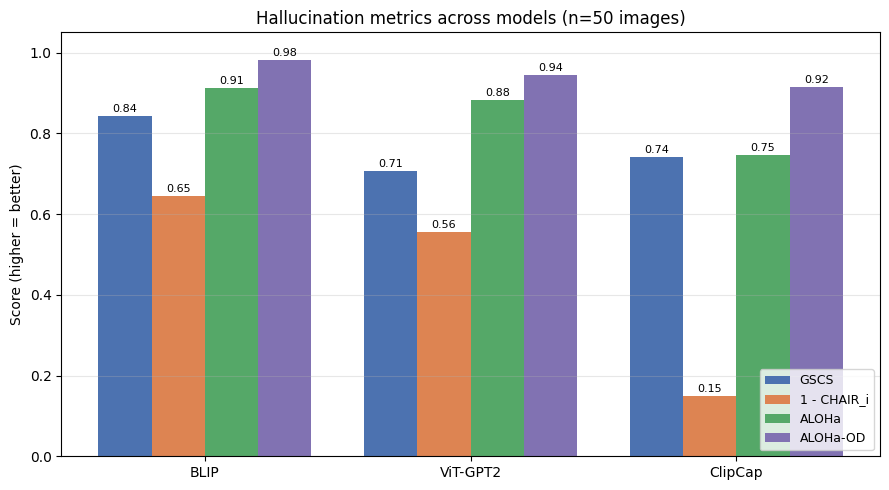

In [14]:
# Plot corpus-level metric bars (3 models x 4 metrics).

metric_labels = ["GSCS", "1 - CHAIR_i", "ALOHa", "ALOHa-OD"]
metric_vals = {
    m: [
        float(summary.loc[summary["model"] == m, "GSCS"].iloc[0]),
        float(1.0 - summary.loc[summary["model"] == m, "CHAIR_i"].iloc[0]),
        float(summary.loc[summary["model"] == m, "ALOHa"].iloc[0]),
        float(summary.loc[summary["model"] == m, "ALOHa_OD"].iloc[0]),
    ]
    for m in models
}

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(models))
width = 0.20
metric_colors = ["#4C72B0", "#DD8452", "#55A868", "#8172B2"]
n_metrics = len(metric_labels)
for i, (label, color) in enumerate(zip(metric_labels, metric_colors)):
    offset = (i - (n_metrics - 1) / 2) * width
    ys = [metric_vals[m][i] for m in models]
    ax.bar(x + offset, ys, width, color=color, label=label)
    for xi, yi in zip(x + offset, ys):
        ax.text(xi, yi + 0.01, f"{yi:.2f}", ha="center", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel("Score (higher = better)")
ax.set_ylim(0, 1.05)
ax.set_title(f"Hallucination metrics across models (n={summary['n_images'].iloc[0]} images)")
ax.legend(fontsize=9, loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "hallucination_metrics_bars.png"),
            dpi=200, bbox_inches="tight")
plt.show()

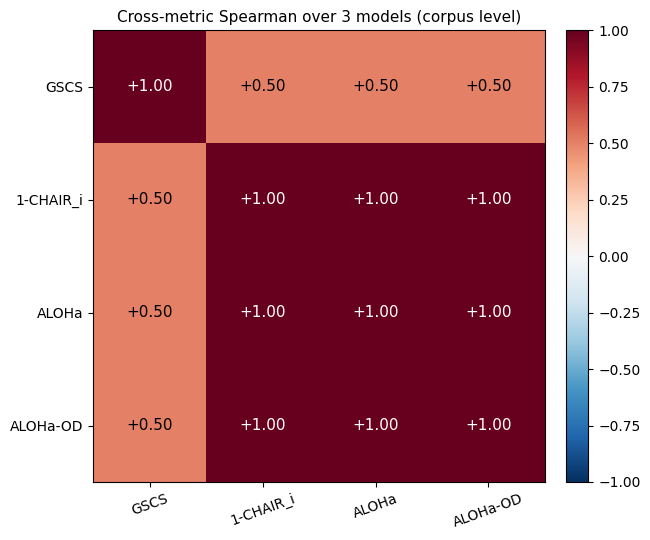

In [15]:
# Plot corpus-level metric correlation matrix (Spearman).

metric_set = ["GSCS", "1-CHAIR_i", "ALOHa", "ALOHa-OD"]
def vec(name):
    if name == "GSCS":
        return summary.set_index("model")["GSCS"].reindex(models).to_numpy()
    if name == "1-CHAIR_i":
        return 1.0 - summary.set_index("model")["CHAIR_i"].reindex(models).to_numpy()
    if name == "ALOHa":
        return summary.set_index("model")["ALOHa"].reindex(models).to_numpy()
    if name == "ALOHa-OD":
        return summary.set_index("model")["ALOHa_OD"].reindex(models).to_numpy()
    raise ValueError(name)

mat = np.zeros((len(metric_set), len(metric_set)))
for i, a in enumerate(metric_set):
    for j, b in enumerate(metric_set):
        va = vec(a); vb = vec(b)
        if np.std(va) == 0 or np.std(vb) == 0:
            mat[i, j] = np.nan
        else:
            mat[i, j] = spearmanr(va, vb)[0]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(mat, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(metric_set))); ax.set_xticklabels(metric_set, fontsize=10, rotation=20)
ax.set_yticks(range(len(metric_set))); ax.set_yticklabels(metric_set, fontsize=10)
for i in range(len(metric_set)):
    for j in range(len(metric_set)):
        v = mat[i, j]
        txt = "n/a" if np.isnan(v) else f"{v:+.2f}"
        ax.text(j, i, txt, ha="center", va="center",
                color="white" if abs(v if not np.isnan(v) else 0) > 0.5 else "black",
                fontsize=11)
ax.set_title("Cross-metric Spearman over 3 models (corpus level)", fontsize=11)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "corpus_level_metric_correlation.png"),
            dpi=200, bbox_inches="tight")
plt.show()

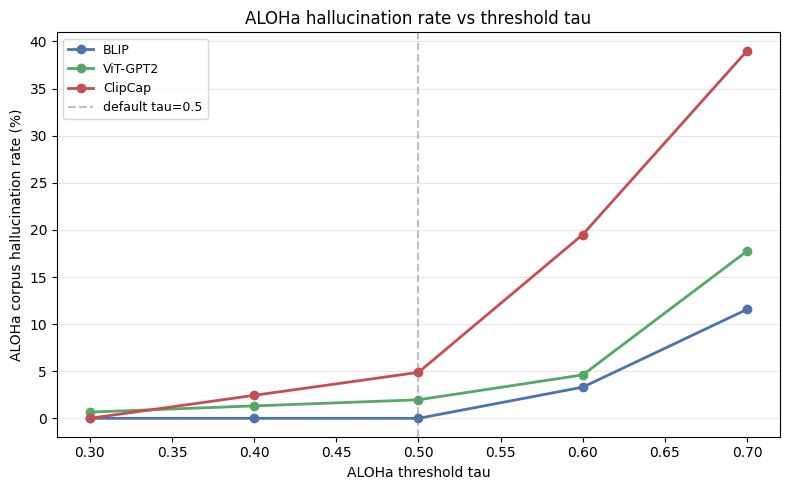

model,BLIP,ClipCap,ViT-GPT2
tau,,,
0.3,0.00,0.00,0.66
0.4,0.00,2.44,1.32
0.5,0.00,4.88,1.97
0.6,3.31,19.51,4.61
0.7,11.57,39.02,17.76


In [16]:
# Sweep ALOHa tau threshold and plot per-model hallucination rate.

TAU_GRID = [0.3, 0.4, 0.5, 0.6, 0.7]
sweep_rows = []
for _, r in aloha_df.iterrows():
    sims = r["aloha_max_sims_per_obj"]
    if not sims:
        for tau in TAU_GRID:
            sweep_rows.append({"model": r["model"], "image": r["image"],
                               "tau": tau, "n_cap_objects": 0,
                               "n_halluc": 0, "aloha_s": 0,
                               "aloha_score": 1.0})
        continue
    for tau in TAU_GRID:
        nh = sum(1 for s in sims if s < tau)
        sweep_rows.append({
            "model": r["model"], "image": r["image"], "tau": tau,
            "n_cap_objects": len(sims),
            "n_halluc": nh,
            "aloha_s": int(nh >= 1),
            "aloha_score": float(np.mean(sims)),
        })
sweep_df = pd.DataFrame(sweep_rows)

sweep_summary = (sweep_df.groupby(["model", "tau"])
    .agg(aloha_corpus_halluc=("n_halluc", lambda s:
             s.sum() / max(sweep_df.loc[s.index, "n_cap_objects"].sum(), 1)),
         aloha_s=("aloha_s", "mean"))
    .reset_index())
sweep_summary["aloha_corpus_halluc_%"] = (sweep_summary["aloha_corpus_halluc"] * 100).round(2)
sweep_summary["aloha_s_%"]              = (sweep_summary["aloha_s"]              * 100).round(2)
sweep_summary.to_csv(os.path.join(RESULTS_DIR, "aloha_tau_sweep.csv"), index=False)

fig, ax = plt.subplots(figsize=(8, 5))
for m in models:
    sub = sweep_summary[sweep_summary["model"] == m].sort_values("tau")
    ax.plot(sub["tau"], sub["aloha_corpus_halluc_%"], marker="o", linewidth=2,
            color=COLOR[m], label=m)
ax.axvline(ALOHA_TAU, color="gray", linestyle="--", alpha=0.5, label=f"default tau={ALOHA_TAU}")
ax.set_xlabel("ALOHa threshold tau")
ax.set_ylabel("ALOHa corpus hallucination rate (%)")
ax.set_title("ALOHa hallucination rate vs threshold tau")
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "aloha_tau_sweep.png"),
            dpi=200, bbox_inches="tight")
plt.show()
sweep_summary.pivot(index="tau", columns="model", values="aloha_corpus_halluc_%")

In [17]:
# Print the final corpus-level summary table.

print("=" * 78)
print(" Hallucination metrics — corpus level (n =",
      summary['n_images'].iloc[0], "images)")
print("=" * 78)
print()
header = (f"{'Model':10s}  {'GSCS':>6s}  {'CHAIR_i':>8s}  {'CHAIR_s':>8s}  "
          f"{'ALOHa':>6s}  {'ALOHa_s':>8s}  {'ALOHa-OD':>9s}")
print(header)
print("-" * len(header))
for _, r in summary.iterrows():
    print(f"{r['model']:10s}  "
          f"{r['GSCS']:>6.3f}  "
          f"{r['CHAIR_i']*100:>7.1f}%  "
          f"{r['CHAIR_s']*100:>7.1f}%  "
          f"{r['ALOHa']:>6.3f}  "
          f"{r['ALOHa_s']*100:>7.1f}%  "
          f"{r['ALOHa_OD']:>9.3f}")

print()
print("Per-image Spearman correlations (GSCS vs others):")
print("-" * 70)
print(corr_per_model.to_string(index=False))

print()
print("Cross-metric Spearman over 3 models (corpus level):")
print("-" * 70)
print(cross_df.to_string(index=False))

print()
print("Saved everything to:", BASE_DIR)

 Hallucination metrics — corpus level (n = 50 images)

Model         GSCS   CHAIR_i   CHAIR_s   ALOHa   ALOHa_s   ALOHa-OD
-------------------------------------------------------------------
BLIP         0.843     35.5%     60.0%   0.911      0.0%      0.981
ClipCap      0.742     85.0%     86.0%   0.747      8.0%      0.915
ViT-GPT2     0.706     44.4%     74.0%   0.882      6.0%      0.945

Per-image Spearman correlations (GSCS vs others):
----------------------------------------------------------------------
   model  gscs_vs_invchair_pearson  gscs_vs_invchair_spearman  gscs_vs_aloha_pearson  gscs_vs_aloha_spearman  gscs_vs_alohaOD_pearson  gscs_vs_alohaOD_spearman  invchair_vs_aloha_pearson  invchair_vs_aloha_spearman  aloha_vs_alohaOD_pearson  aloha_vs_alohaOD_spearman
    BLIP                    -0.040                     -0.100                 -0.103                  -0.098                    0.607                     0.615                      0.884                       0.918 

In [18]:
zip_path = os.path.join(OUTPUTS_DIR, "hallucination_outputs.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for folder in (RESULTS_DIR, FIGURES_DIR):
        for root, _, files in os.walk(folder):
            for name in files:
                full = os.path.join(root, name)
                zf.write(full, os.path.relpath(full, BASE_DIR))

print("Wrote zip:", zip_path)
print("Files in zip:")
with zipfile.ZipFile(zip_path) as zf:
    for n in zf.namelist():
        print("  ", n)

Wrote zip: c:\Users\William\Desktop\Vision2Text\Vision2Text\outputs\hallucination_outputs.zip
Files in zip:
   results/aloha_per_image.csv
   results/aloha_summary.csv
   results/aloha_tau_sweep.csv
   results/chair_per_image.csv
   results/correlation_matrix.csv
   results/hallucination_summary.csv
   results/metrics_per_image.csv
   results/ranking_agreement.csv
   results/ranking_agreement_spearman.csv
   figures/aloha_tau_sweep.png
   figures/corpus_level_metric_correlation.png
   figures/gscs_vs_chair_aloha_scatter.png
   figures/hallucination_metrics_bars.png
   figures/per_model_correlation_heatmap.png
